In [1]:
import numpy as np
import matplotlib.pyplot as plt

$$
\textcolor{yellow}{
\alpha = \gamma \int_{-1}^{+1}\mathrm{d}q G(q),}
$$

$$
\textcolor{yellow}{
G(q) = \frac{1}{2\pi} +\int_{-1}^{+1}\frac{dq^{\prime}}{2\pi} G(q^{\prime})\frac{2\alpha}{(q^{\prime} - q)^{2} + \alpha^{2}},}
$$

$$
e(\gamma) = \left( \frac{\gamma}{\alpha(\gamma)} \right)^3 \int_{-1}^{+1} dq \, G(q; \gamma) q^2.
$$

$$
\mu = \left. \frac{\partial E}{\partial N} \right|_L = \frac{\hbar^2}{2m} n^2 \left[ 3e(\gamma) - \gamma e'(\gamma) \right].
$$

In [2]:
def bethe (γ,max_iter=1000, ϵ=1e-10):
    #α和G(q)只是中间过程，bethe ansatz的最终目的是由γ求出e(γ)
    q=np.linspace(-1,1,200)
    dq=q[1]-q[0]
    
    α=np.zeros_like(γ)
    G =np.zeros((len(q),len(γ)))
    e =np.zeros_like(γ)
    
    #G_old,α_old用来暂存
    G_old=np.zeros((len(q),len(γ)))
    α_old=np.zeros_like(γ)
    
        
    for iγ in range (len(γ)):
        print(f"计算γ={γ[iγ]:.3f}")
        
        if iγ==0:
            #总迭代开启条件
            for iq in range (len(q)):
                G[iq][0]=1/(2*np.pi)
            α[0]=1000
        else:
            #e.g.用γ=100的最终G和α当作γ=95的起始
            for iq in range (len(q)):
                G[iq][iγ]=G[iq][iγ-1]
            α[iγ]=α[iγ-1]
        
        for ite in range(max_iter):
            
            #复制G,α到G_old, α_old
            for jq in range(len(q)):
                G_old[jq][iγ]=G[jq][iγ]
            α_old[iγ]=α[iγ]

            #f为G(q)自洽迭代中的被积函数
            f=np.zeros((len(q),len(q)))
            for iq in range(len(q)):
                for jq in range(len(q)):
                    f[iq][jq]=(G_old[jq][iγ]/np.pi)*α[iγ]/((q[jq]-q[iq])**2+α[iγ]**2)

            #数值积分更新G(q)
            for iq in range(len(q)):
                intval=0
                for jq in range(len(q)-1):
                    intval+= (dq/2)*(f[iq][jq]+f[iq][jq+1])
                G[iq][iγ]=1/(2*np.pi)+intval
            #数值积分更新α
            intval=0
            for iq in range(len(q)-1):
                intval+= (dq/2)*(G[iq][iγ]+G[iq+1][iγ])
            α[iγ]=γ[iγ]*intval

            
            #G(q),α更新前和更新后的差 (范数) 
            diff_G=0
            diff_α=0
            for iq in range(len(q)):   
                diff_G+= (G_old[iq][iγ]-G[iq][iγ])**2
            diff_G=abs(diff_G)
            diff_α=abs(α[iγ]-α_old[iγ])
            
            
            if diff_G<ϵ and diff_α<ϵ:
                print(f"  γ={γ[iγ]:.3f}, 迭代{ite+1}次后收敛")
                break   
            if ite==max_iter-1:
                print(f"  γ={γ[iγ]:.3f}, 达到最大迭代次数{max_iter}!")
    
    #完成上面对γ的循环，将得到最终解G(q)和α
    #数值积分计算e(γ)
    for iγ in range(len(γ)):
        intval=0
        for iq in range(len(q)-1):
            intval+= (dq/2)*(G[iq][iγ]*(q[iq]**2)+G[iq+1][iγ]*(q[iq+1]**2))
        e[iγ]=((γ[iγ]/α[iγ])**3)*intval
    
    return e
            
        
       

**非均匀网格中心差分导数**

考虑三个非均匀网格点：$x_{i-1}$, $x_i$, $x_{i+1}$，对应的函数值为$f_{i-1}$, $f_i$, $f_{i+1}$。

定义：
$$
h_1 = x_i - x_{i-1}, \quad h_2 = x_{i+1} - x_i
$$

在$x_i$处对$f_{i-1}$和$f_{i+1}$进行泰勒展开：

$$
\begin{aligned}
f_{i-1} &= f_i - h_1 f'_i + \frac{h_1^2}{2} f''_i - \frac{h_1^3}{6} f'''_i + O(h_1^4) \quad (1) \\
f_{i+1} &= f_i + h_2 f'_i + \frac{h_2^2}{2} f''_i + \frac{h_2^3}{6} f'''_i + O(h_2^4) \quad (2)
\end{aligned}
$$

消去$f''_i$项，解出$f'_i$,忽略高阶项，得到：

$$
f'_i = \frac{h_1^2 f_{i+1} + (h_2^2 - h_1^2) f_i - h_2^2 f_{i-1}}{h_1 h_2 (h_1 + h_2)}
$$

当$h_1 = h_2 = h$时，退化为均匀的中心差分：

$$
f'_i = \frac{f_{i+1} - f_{i-1}}{2h}
$$


In [3]:
def μ_dimless (γ,e):
    dedγ=np.zeros_like(γ)
    μ_dl=np.zeros_like(γ)
    #内部点中心差分
    for i in range(1,len(γ)-1):
        h1=γ[i]-γ[i-1]
        h2=γ[i+1]-γ[i]
        dedγ[i]=(h1**2*e[i+1]+(h2**2-h1**2)*e[i]-h2**2*e[i-1])/(h1*h2*(h1+h2))
    #边界点前后差分
    dedγ[0]=(e[1]-e[0])/(γ[1]-γ[0])
    dedγ[-1]=(e[-1]-e[-2])/(γ[-1]-γ[-2])
    
    for i in range(len(γ)):
        μ_dl[i]=3*e[i]-γ[i]*dedγ[i]
    return μ_dl    

计算γ=100.000
  γ=100.000, 迭代5次后收敛
计算γ=70.000
  γ=70.000, 迭代5次后收敛
计算γ=50.000
  γ=50.000, 迭代5次后收敛
计算γ=30.000
  γ=30.000, 迭代5次后收敛
计算γ=20.000
  γ=20.000, 迭代6次后收敛
计算γ=15.000
  γ=15.000, 迭代6次后收敛
计算γ=10.000
  γ=10.000, 迭代7次后收敛
计算γ=7.000
  γ=7.000, 迭代8次后收敛
计算γ=5.000
  γ=5.000, 迭代9次后收敛
计算γ=3.000
  γ=3.000, 迭代12次后收敛
计算γ=2.000
  γ=2.000, 迭代14次后收敛
计算γ=1.500
  γ=1.500, 迭代16次后收敛
计算γ=1.000
  γ=1.000, 迭代19次后收敛
计算γ=0.700
  γ=0.700, 迭代22次后收敛
计算γ=0.500
  γ=0.500, 迭代26次后收敛
计算γ=0.300
  γ=0.300, 迭代33次后收敛
计算γ=0.200
  γ=0.200, 迭代39次后收敛
计算γ=0.150
  γ=0.150, 迭代43次后收敛
计算γ=0.100
  γ=0.100, 迭代53次后收敛
计算γ=0.070
  γ=0.070, 迭代61次后收敛
计算γ=0.050
  γ=0.050, 迭代71次后收敛
计算γ=0.030
  γ=0.030, 迭代91次后收敛
计算γ=0.020
  γ=0.020, 迭代107次后收敛
计算γ=0.015
  γ=0.015, 迭代119次后收敛
计算γ=0.010
  γ=0.010, 迭代145次后收敛
计算γ=0.007
  γ=0.007, 迭代168次后收敛
计算γ=0.005
  γ=0.005, 迭代194次后收敛
计算γ=0.003
  γ=0.003, 迭代249次后收敛
计算γ=0.002
  γ=0.002, 迭代292次后收敛
计算γ=0.002
  γ=0.002, 迭代321次后收敛
计算γ=0.001
  γ=0.001, 迭代384次后收敛


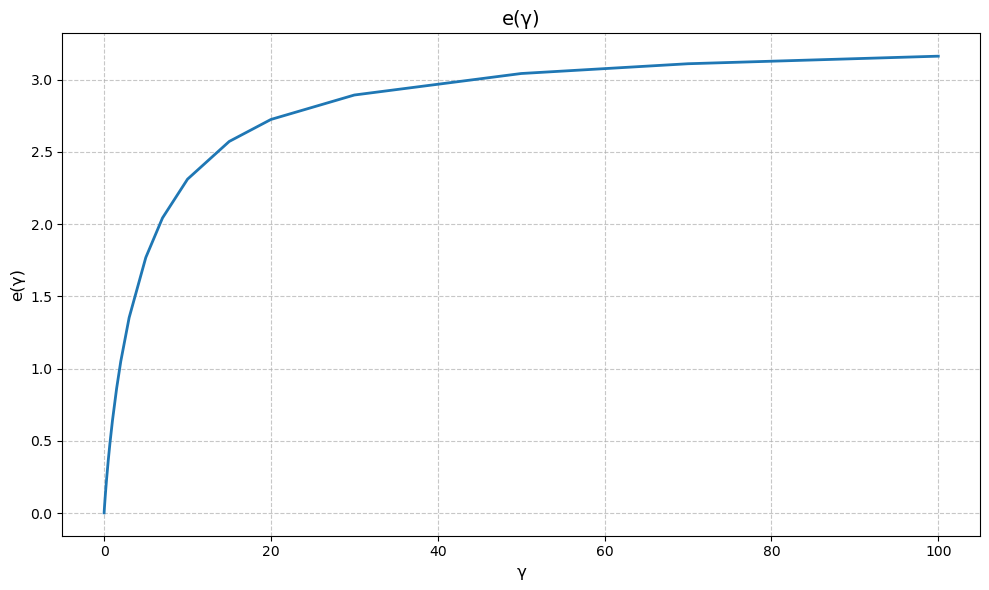

In [4]:
#γ=np.linspace(1,100,100)
#γ = np.logspace(-3, 2, 30)
γ = np.array([100, 70,50, 30, 20, 15, 10, 7, 5, 3, 2, 1.5, 1, 0.7, 0.5, 0.3, 0.2, 0.15, 0.1, 0.07, 0.05, 0.03, 0.02, 0.015, 0.01, 0.007, 0.005, 0.003, 0.002, 0.0015, 0.001])
γ = np.sort(γ)[::-1]
e= bethe(γ)


# 创建图形
plt.figure(figsize=(10, 6))  # 设置图形大小（可选）

# 绘制平滑曲线
plt.plot(γ,e, linewidth=2)  

# 添加标签和标题
plt.xlabel('γ', fontsize=12)
plt.ylabel('e(γ)', fontsize=12)
plt.title('e(γ)', fontsize=14)

# 添加网格线（可选）
plt.grid(True, linestyle='--', alpha=0.7)

# 显示图形
plt.tight_layout()  # 自动调整布局
plt.show()

In [5]:
#!pip install SciencePlots
#运行上面语句一次就已经把该包永久装到本地anlacoda目录！
import scienceplots

In [6]:
μ_dl=np.zeros_like(γ)
μ_dl=μ_dimless(γ,e)
y=np.zeros_like(γ)
x=np.zeros_like(γ)
for i in range (len(γ)):
    y[i]=1/γ[i]
    x[i]=μ_dl[i]/(2*γ[i]**2)

In [7]:
yinfy=np.zeros_like(γ)
ybb1=np.zeros_like(γ)
y0=np.zeros_like(γ)
yss1=np.zeros_like(γ)
for i in range(len(γ)):
    yinfy[i]=(2*x[i]/np.pi**2)**(1/2)
    ybb1[i]=yinfy[i]+8*x[i]/(3*np.pi)-2*(2**0.5)/(np.pi**2)*(x[i])**1.5
    y0[i]=x[i]
    yss1[i]=y0[i]+1/np.pi*(x[i]**0.5) 
    
yinfy[x > 10**(-7/4)] = np.nan  # 画图时不显示的部分
ybb1[x > 10**(-7/4)] = np.nan  
y0[x < 10**(-5/4)] = np.nan  
yss1[x < 10**(-5/4)] = np.nan  

$正无穷$
$$
n = \sqrt{\frac{2m\mu}{\pi^2\hbar^2}}.
$$
$远大于1$
$$
n = \sqrt{\frac{2m\mu}{\pi^2\hbar^2}} + \frac{8\mu}{3\pi g} - \frac{2\sqrt{2}\hbar\mu^{1.5}}{\pi^2g^2\sqrt{m}}.
$$
$趋于0$
$$
n = \frac{\mu}{g},
$$
$远小于1$
$$
n = \frac{\mu}{g} + \frac{1}{\pi} \sqrt{\frac{m\mu}{\hbar^2}}.
$$

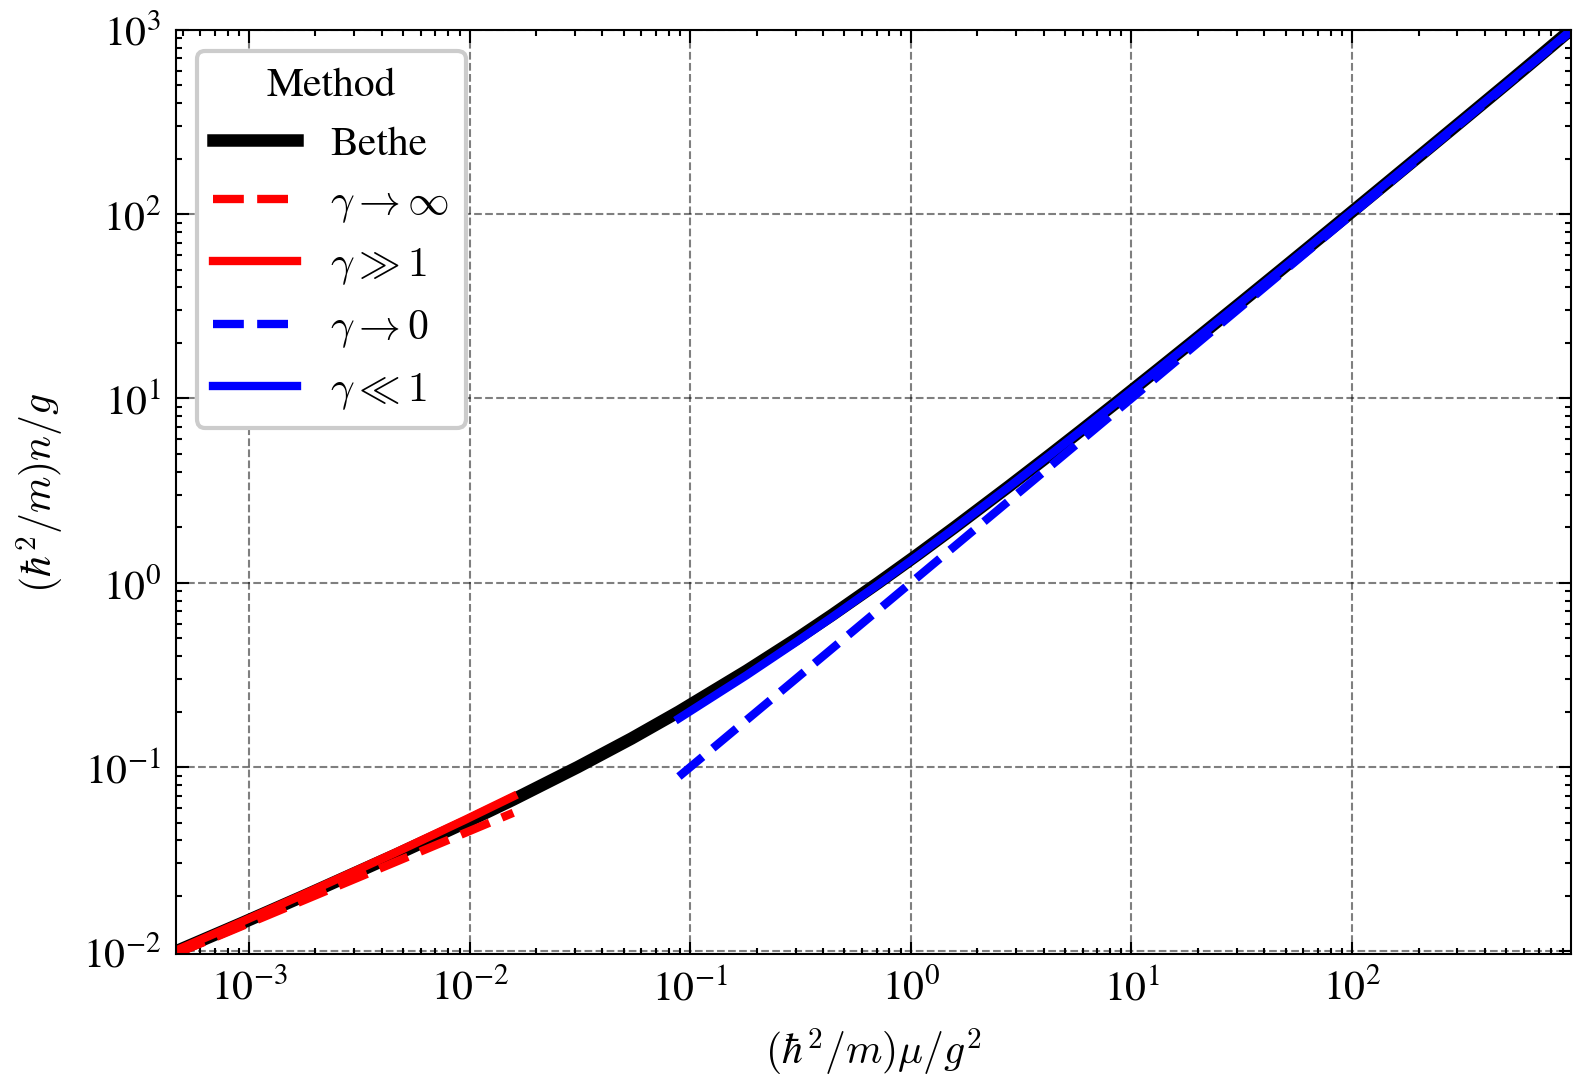

In [8]:
pparam = dict(ylabel=r"$( \hbar ^2/m ) n/g$",
              xlabel=r"$( \hbar ^2/m ) \mu /g^2$") 

with plt.style.context(['science', 'no-latex', 'grid']):
    #如果不加no-latex，scienceplot会把图中的latex公式按本地部署的latex公式编译，如果没有部署会导致报错
    fig, ax = plt.subplots(figsize = (6,4),dpi = 300)

    ax.loglog(x, y, 'k-', linewidth=3, label='Bethe')
    ax.loglog(x, yinfy, 'r--', linewidth=2,label=r'$\gamma \rightarrow \infty $')
    ax.loglog(x, ybb1, 'r-', linewidth=2, label=r'$\gamma \gg 1$')
    ax.loglog(x, y0, 'b--', linewidth=2, label=r'$\gamma \rightarrow 0 $')
    ax.loglog(x, yss1, 'b-', linewidth=2, label=r'$\gamma \ll 1$')
    
    ax.legend(title="Method")# 添加图例和其标题
    ax.autoscale(tight=True)# 不会在数据点边缘留出额外的空白
    ax.set(**pparam)# 接收前面设置的横、纵坐标参数
    plt.show()